In [1]:
# histopatolojik meme kanseri görüntülerinin U-Net tabanlı segmentasyon, ROI çıkarımı, 
# MobileNetV2 sınıflandırması ve Grad-CAM açıklanabilirliği 

# ÖZGÜNLÜK-U-Net ile önce lezyon buluyorum
#Sonra bu bilgiyi sınıflandırmaya aktarıyorum
#Ardından Grad-CAM ile kararı görselleştiriliyorum
#Yani Segmentasyon → ROI → Sınıflandırma → Açıklama
#tek bir sistem içinde karşılaştırmalı olarak inceleniyor.
#Literatürde bu adımlar genelde: ya ayrı ayrı , ya da açıklamasız şekilde yapılıyor


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

print(os.listdir("/kaggle/input"))

['breast-dataset', 'u-net-dat']


In [2]:
import os

print(os.listdir("/kaggle/input/u-net-dat"))

['u-net dataset']


In [3]:

import os

base = "/kaggle/input/u-net-dat"

for item in os.listdir(base):
    print(item, "→", os.listdir(os.path.join(base, item)) if os.path.isdir(os.path.join(base, item)) else "")

u-net dataset → ['images', 'masks']


In [4]:
import os

UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"

UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")

print("Image folder exists:", os.path.exists(UNET_IMAGE_PATH))
print("Mask folder exists :", os.path.exists(UNET_MASK_PATH))

print("Image classes:", os.listdir(UNET_IMAGE_PATH))
print("Mask classes :", os.listdir(UNET_MASK_PATH))

Image folder exists: True
Mask folder exists : True
Image classes: ['benign', 'malignant']
Mask classes : ['benign', 'malignant']


In [5]:

import os

UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"
UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")


for cls in ["benign", "malignant"]:
    img_dir = os.path.join(UNET_IMAGE_PATH, cls)
    mask_dir = os.path.join(UNET_MASK_PATH, cls)

    imgs = sorted(os.listdir(img_dir))
    masks = sorted(os.listdir(mask_dir))

    print(f"\nClass: {cls}")
    print("Image count:", len(imgs))
    print("Mask  count:", len(masks))

    # İsim eşleşme kontrolü (ilk 5)
    for i in range(5):
        print(" ", imgs[i], "↔", masks[i])


Class: benign
Image count: 210
Mask  count: 210
  benign (1).png ↔ benign (1)_mask.png
  benign (10).png ↔ benign (10)_mask.png
  benign (100).png ↔ benign (100)_mask.png
  benign (101).png ↔ benign (101)_mask.png
  benign (102).png ↔ benign (102)_mask.png

Class: malignant
Image count: 210
Mask  count: 210
  malignant (1).png ↔ malignant (1)_mask.png
  malignant (10).png ↔ malignant (10)_mask.png
  malignant (100).png ↔ malignant (100)_mask.png
  malignant (101).png ↔ malignant (101)_mask.png
  malignant (102).png ↔ malignant (102)_mask.png


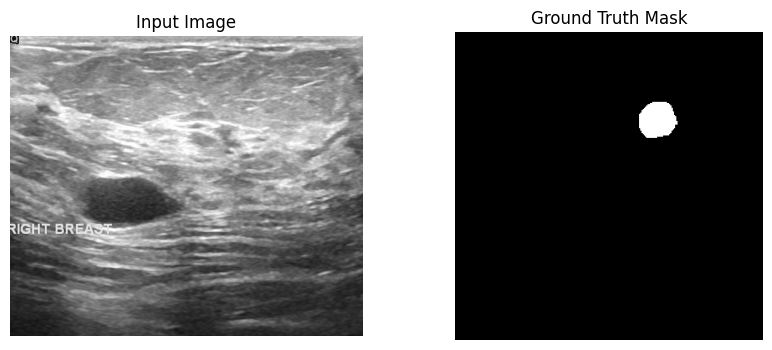

Mask min/max: 0.0 1.0
Mask shape: (256, 256, 1)


In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Base paths
UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"
UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")

# Seçmek istediğin sınıf
cls = "benign"  # veya "malignant"

# Class klasörlerinin tam yolu
img_dir  = os.path.join(UNET_IMAGE_PATH, cls)
mask_dir = os.path.join(UNET_MASK_PATH, cls)

# Örnek resim ve mask seç
img_name  = os.listdir(img_dir)[0]
mask_name = os.listdir(mask_dir)[0]

img_path  = os.path.join(img_dir, img_name)
mask_path = os.path.join(mask_dir, mask_name)

# Görüntüyü yükle ve normalize et
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Maskeyi yükle ve binary yap
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (256, 256))           # UNet input boyutu
mask = (mask > 0).astype("float32")           # Binary mask
mask = np.expand_dims(mask, axis=-1)

# Görselleştir
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,0], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

print("Mask min/max:", mask.min(), mask.max())
print("Mask shape:", mask.shape)

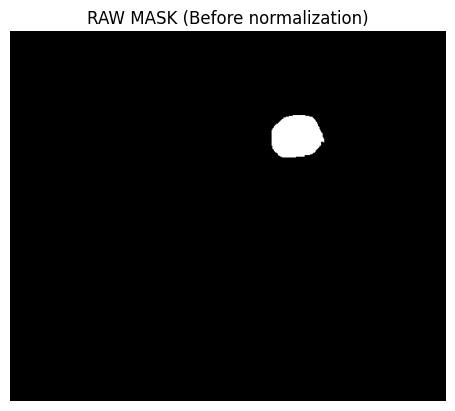

Raw mask min-max: 0 255


In [7]:
raw_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(raw_mask, cmap="gray")
plt.title("RAW MASK (Before normalization)")
plt.axis("off")
plt.show()

print("Raw mask min-max:", raw_mask.min(), raw_mask.max())

In [8]:
mask = (raw_mask > 0).astype("float32")

# KÜÇÜK TÜMÖR PROBLEMİ ÇÖZÜMÜ
kernel = np.ones((3,3), np.uint8)
mask = cv2.dilate(mask, kernel, iterations=1)

mask = np.expand_dims(mask, axis=-1)

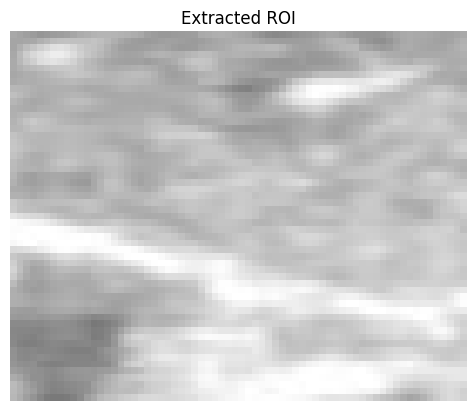

In [9]:
ys, xs = np.where(mask.squeeze() == 1)

if len(xs) > 0:
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    roi = img[y_min:y_max, x_min:x_max]

    plt.imshow(roi)
    plt.title("Extracted ROI")
    plt.axis("off")
    plt.show()
else:
    print("ROI bulunamadı")

In [10]:
# -------------------------------
# 1️⃣ Gerekli kütüphaneler
# -------------------------------
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

    # 2️⃣ ResNet50-backbonlu U-Net (256x256 output)
def build_resnet_unet_256(input_size=(256,256,3)):
    # Encoder (ResNet50)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_size
        
    )
    base_model.trainable = False


    # Encoder katmanları (skip connections)
    s1 = base_model.get_layer("conv1_relu").output         # 128x128
    s2 = base_model.get_layer("conv2_block3_out").output   # 64x64
    s3 = base_model.get_layer("conv3_block4_out").output   # 32x32
    s4 = base_model.get_layer("conv4_block6_out").output   # 16x16

    b  = base_model.get_layer("conv5_block3_out").output   # 8x8

    # -------- Decoder --------
    # d1: 8x8 -> 16x16
    d1 = UpSampling2D(size=(2,2))(b)
    d1 = Concatenate()([d1, s4])
    d1 = Conv2D(512, 3, padding="same", activation="relu")(d1)

    # d2: 16x16 -> 32x32
    d2 = UpSampling2D(size=(2,2))(d1)
    d2 = Concatenate()([d2, s3])
    d2 = Conv2D(256, 3, padding="same", activation="relu")(d2)

    # d3: 32x32 -> 64x64
    d3 = UpSampling2D(size=(2,2))(d2)
    d3 = Concatenate()([d3, s2])
    d3 = Conv2D(128, 3, padding="same", activation="relu")(d3)

    # d4: 64x64 -> 128x128
    d4 = UpSampling2D(size=(2,2))(d3)
    d4 = Concatenate()([d4, s1])
    d4 = Conv2D(64, 3, padding="same", activation="relu")(d4)

    # d5: 128x128 -> 256x256 (final upsampling)
    d5 = UpSampling2D(size=(2,2))(d4)
    d5 = Conv2D(32, 3, padding="same", activation="relu")(d5)

    # Output layer
    outputs = Conv2D(1, 1, activation="sigmoid")(d5)   # 256x256 output

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

    # 3️⃣ Modeli oluştur
unet = build_resnet_unet_256()

2026-02-25 11:48:21.899559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772020102.247491      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772020102.348620      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772020103.225598      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772020103.225635      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772020103.225637      55 computation_placer.cc:177] computation placer alr

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [11]:
import cv2
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Concatenate, BatchNormalization, Dropout, Activation
)

def unet_generator(img_dir, mask_dir, batch_size=8, target_size=(256,256)):

    img_paths  = []
    mask_paths = []

    for cls in ["benign", "malignant"]:

        img_cls_dir  = os.path.join(img_dir, cls)
        mask_cls_dir = os.path.join(mask_dir, cls)

        imgs  = sorted(os.listdir(img_cls_dir))
        masks = sorted(os.listdir(mask_cls_dir))


        for img_name in imgs:

            # .png kaldır
            base = img_name.replace(".png", "")

            # mask ismi oluştur
            mask_name = base + "_mask.png"

            if mask_name in masks:

                img_paths.append(
                    os.path.join(img_cls_dir, img_name)
                )

                mask_paths.append(
                    os.path.join(mask_cls_dir, mask_name)
                )


    N = len(img_paths)
    print("Total matched samples:", N)


    while True:

        idxs = np.random.permutation(N)

        for i in range(0, N, batch_size):

            batch_idx = idxs[i:i+batch_size]

            imgs, masks = [], []


            for j in batch_idx:

                # ---------- IMAGE ----------
                img = cv2.imread(img_paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img.astype(np.float32) / 255.0


                # ---------- MASK ----------
                mask = cv2.imread(mask_paths[j], cv2.IMREAD_GRAYSCALE)

                if mask is None:
                    print("MASK NOT FOUND:", mask_paths[j])
                    continue


                mask = cv2.resize(
                    mask,
                    target_size,
                    interpolation=cv2.INTER_NEAREST
                )

                mask = (mask > 127).astype(np.float32)
                mask = np.expand_dims(mask, -1)


                # ---------- AUGMENT ----------
                if np.random.rand() < 0.5:
                    img  = np.fliplr(img)
                    mask = np.fliplr(mask)

                if np.random.rand() < 0.3:

                    angle = np.random.uniform(-10, 10)

                    M = cv2.getRotationMatrix2D(
                        (target_size[0]//2, target_size[1]//2),
                        angle,
                        1
                    )

                    img = cv2.warpAffine(img, M, target_size)

                    mask = cv2.warpAffine(
                        mask,
                        M,
                        target_size,
                        flags=cv2.INTER_NEAREST
                    )

                    mask = np.expand_dims(mask, -1)


                # ---------- APPEND ----------
                imgs.append(img)
                masks.append(mask)


            if len(imgs) == 0:
                continue


            yield np.array(imgs), np.array(masks)

In [12]:
TRAIN_IMG_DIR = UNET_IMAGE_PATH
TRAIN_MASK_DIR = UNET_MASK_PATH

batch_size = 8
train_gen = unet_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, batch_size=batch_size)

In [13]:
gen = unet_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, batch_size=4)

x, y = next(gen)

print("X shape:", x.shape)
print("Y shape:", y.shape)

print("Mask unique:", np.unique(y))

Total matched samples: 420
X shape: (4, 256, 256, 3)
Y shape: (4, 256, 256, 1)
Mask unique: [0. 1.]


In [14]:
# 4️⃣ Compile (focal + dice loss veya istediğin loss)
def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - tf.reduce_mean(dice)

def focal_loss(y_true, y_pred, alpha=0.8, gamma=2.0):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    pt = tf.exp(-bce)
    return tf.reduce_mean(alpha * (1-pt)**gamma * bce)

def focal_dice_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    return tf.reduce_mean((2. * intersection + 1e-6) / (union + 1e-6))

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=5,
        factor=0.5,
        verbose=1
    )
]

In [16]:
# Image -> 0-1 normalize
img = img / 255.0

size = (256,256)
# Mask -> 0-1 binary
mask = (mask > 0).astype(np.float32)
mask = np.expand_dims(mask, axis=-1)

In [17]:
import os

# Train dizinlerindeki görüntü sayısı
num_benign    = len(os.listdir(os.path.join(TRAIN_IMG_DIR, "benign")))
num_malignant = len(os.listdir(os.path.join(TRAIN_IMG_DIR, "malignant")))

total_images = num_benign + num_malignant

batch_size = 8  # Generator batch_size'ına göre

# Bir epoch için gerekli adım sayısı
steps_per_epoch = total_images // batch_size

In [18]:

from tensorflow.keras.optimizers import Adam
# Compile
unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_dice_loss,
    metrics=[dice_coef]
)
history = unet.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    callbacks=callbacks
)

Total matched samples: 420
Epoch 1/50


I0000 00:00:1772020134.327482     130 service.cc:152] XLA service 0x79bb0c002250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772020134.327536     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772020136.513481     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - dice_coef: 0.1422 - loss: 1.1073  

I0000 00:00:1772020146.654828     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - dice_coef: 0.1911 - loss: 0.9183 - learning_rate: 1.0000e-04
Epoch 2/50


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: dice_coef,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: dice_coef,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-02-25 11:49:18.871347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 11:49:19.133501: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - dice_coef: 0.2528 - loss: 0.8420 - learning_rate: 1.0000e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.2338 - loss: 0.8517 - learning_rate: 1.0000e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.2454 - loss: 0.8421 - learning_rate: 1.0000e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - dice_coef: 0.2410 - loss: 0.8408 - learning_rate: 1.0000e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.2494 - loss: 0.8422 - learning_rate: 1.0000e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - dice_coef: 0.2486 - loss: 0.8279 - learning_rate: 1.0000e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - dice_coef: 0.2533 - loss: 0.8229 - learning_rate: 1.0000e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.2508 - loss: 0.8347 - learning_rate: 1.0000e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.2486 - loss: 0.8310 - learning_

In [19]:
for layer in unet.layers[-40:]:
    layer.trainable = True

In [20]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss=focal_dice_loss,
    metrics=[dice_coef]
)
history2 = unet.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 228ms/step - dice_coef: 0.3218 - loss: 0.8520 - learning_rate: 5.0000e-05
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.4172 - loss: 0.6968 - learning_rate: 5.0000e-05
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - dice_coef: 0.4368 - loss: 0.6739 - learning_rate: 5.0000e-05
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - dice_coef: 0.4355 - loss: 0.6936 - learning_rate: 5.0000e-05
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - dice_coef: 0.4417 - loss: 0.6871 - learning_rate: 5.0000e-05
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - dice_coef: 0.4600 - loss: 0.6515 - learning_rate: 5.0000e-05
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - dice_coef: 0.4525 - loss: 0.6615 - learning_rate: 5.0000e-05
Epoch 8/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - dice_coef: 0.5068 - loss: 0.5938 - learning_rate: 5.0000e-05
Epoch 9/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - dice_coef: 0.5229 - loss: 0.5911 

In [21]:
# Eğitim bittikten sonra
unet.save("/kaggle/working/unet_full_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Dice score on batch: 0.5803891


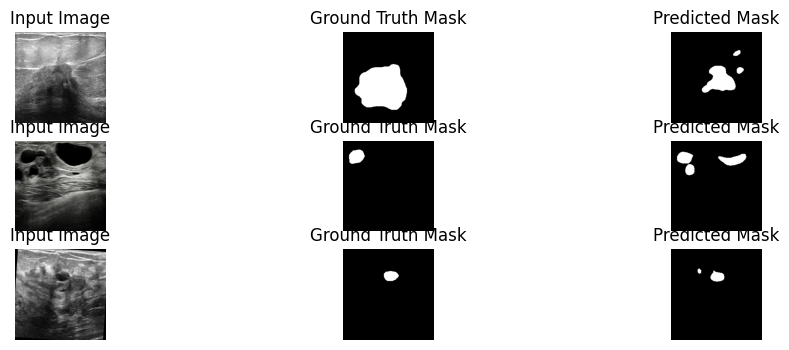

In [22]:
# Generator’dan bir batch al
x_batch, y_batch = next(train_gen)

# Model ile tahmin
pred_mask = unet.predict(x_batch)

# Binary mask
pred_mask_bin = (pred_mask > 0.4).astype(np.float32)

# Dice score batch için
intersection = np.sum(pred_mask_bin * y_batch)
union = np.sum(pred_mask_bin) + np.sum(y_batch)
dice_score = (2*intersection + 1e-3) / (union + 1e-6)
print("Dice score on batch:", dice_score)

# Görselleştirme
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
for i in range(3):  # ilk 3 örnek
    plt.subplot(3,3,i*3+1)
    plt.imshow(x_batch[i])
    plt.title("Input Image")
    plt.axis("off")
    
    plt.subplot(3,3,i*3+2)
    plt.imshow(y_batch[i,:,:,0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(3,3,i*3+3)
    plt.imshow(pred_mask_bin[i,:,:,0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")
plt.show()


In [23]:
x_batch, y_batch = next(train_gen)

pred = unet.predict(x_batch)

print("Pred min/max:", pred.min(), pred.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Pred min/max: 3.6493237e-27 0.99985325


In [24]:
unet = tf.keras.models.load_model(
    "/kaggle/working/unet_full_model.h5",
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

In [25]:
import os
print(os.listdir("/kaggle/input/breast-dataset"))

['breast_dataset']


In [26]:
print(os.listdir("/kaggle/input/breast-dataset/breast_dataset"))

['val', 'test', 'train']


In [27]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
base_path = "/kaggle/input/breast-dataset/breast_dataset/train/malignant"
print(os.listdir(base_path)[:8]);

['10262_idx5_x1351_y951_class1.png', '10262_idx5_x1251_y1951_class1.png', '10264_idx5_x1101_y1451_class1.png', '10273_idx5_x1901_y1701_class1.png', '10277_idx5_x1051_y951_class1.png', '10275_idx5_x1101_y851_class1.png', '10273_idx5_x851_y751_class1.png', '10254_idx5_x1751_y1251_class1.png']


In [28]:
base_path = "/kaggle/input/breast-dataset/breast_dataset/train/malignant"

img_name = os.listdir(base_path)[0]
img_path = os.path.join(base_path, img_name)

In [29]:
def preprocess_for_unet(img_path, size=(256,256)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img.astype(np.float32)/255.0
    return img

In [30]:
img_unet = preprocess_for_unet(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Mask pixels: 25846


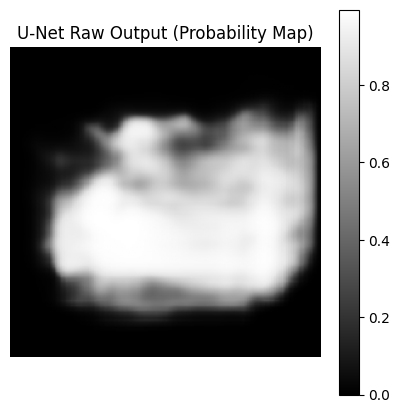

In [31]:
pred = unet.predict(img_unet[None,...])[0]

# Adaptif threshold
th = 0.5 * pred.max()

binary = (pred > th).astype(np.uint8)

# En büyük bölgeyi al
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    binary = (labels == largest).astype(np.uint8)

# Temizleme
kernel = np.ones((5,5), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

print("Mask pixels:", np.sum(binary))


# --- RAW U-NET OUTPUT ---
plt.figure(figsize=(5,5))
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("U-Net Raw Output (Probability Map)")
plt.colorbar()
plt.axis("off")
plt.show()

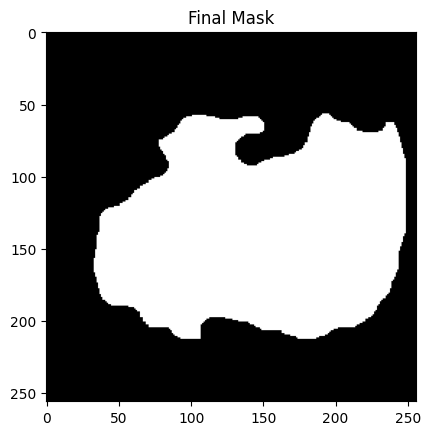

In [32]:
plt.imshow(binary, cmap="gray")
plt.title("Final Mask")
plt.show()

In [33]:
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

Pred min/max: 4.0407783e-25 0.9948483


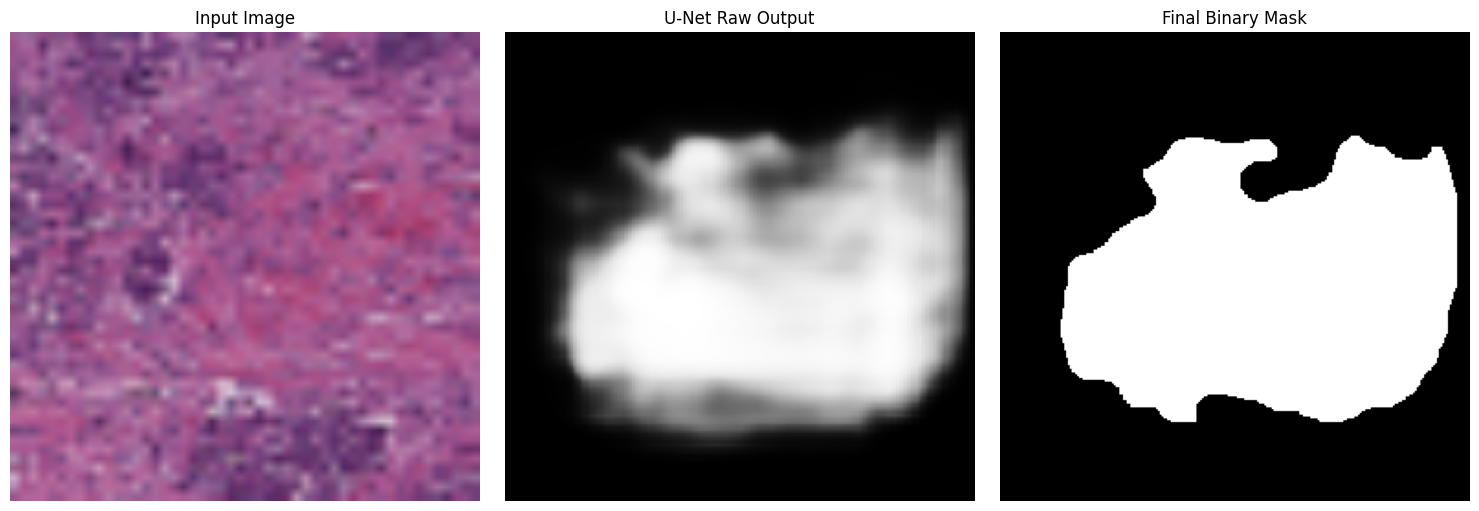

In [34]:
print("Pred min/max:", pred.min(), pred.max())
plt.figure(figsize=(15,5))

# Input
plt.subplot(1,3,1)
plt.imshow(img_unet)
plt.title("Input Image")
plt.axis("off")

# Raw U-Net Output
plt.subplot(1,3,2)
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("U-Net Raw Output")
plt.axis("off")

# Final Binary Mask
plt.subplot(1,3,3)
plt.imshow(binary, cmap="gray")
plt.title("Final Binary Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

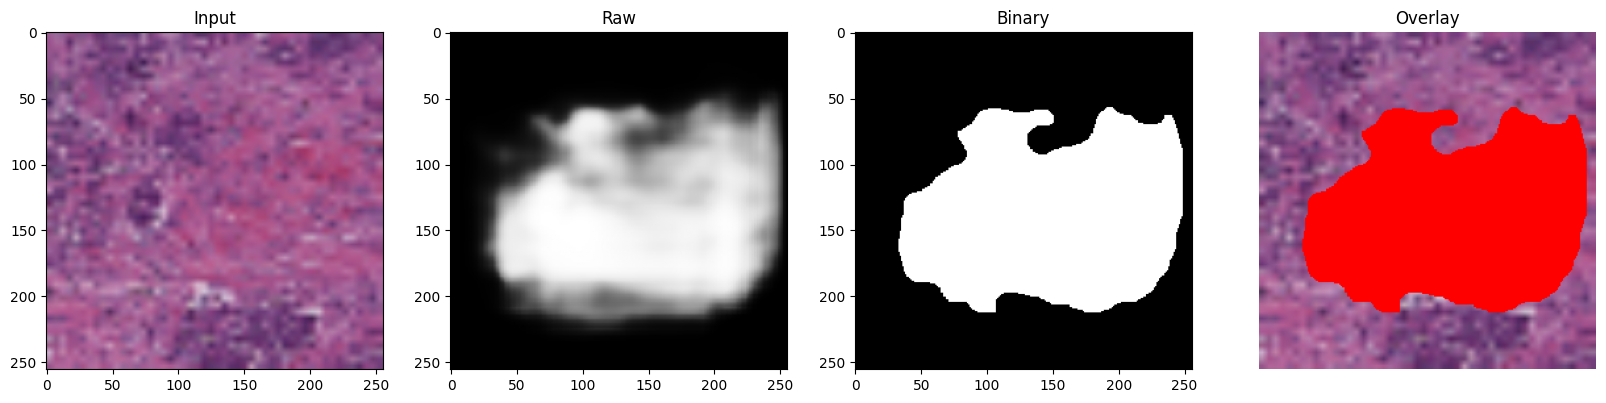

In [35]:
overlay = img_unet.copy()
overlay[binary == 1] = [255, 0, 0]

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(img_unet)
plt.title("Input")

plt.subplot(1,4,2)
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("Raw")

plt.subplot(1,4,3)
plt.imshow(binary, cmap="gray")
plt.title("Binary")

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Overlay")

plt.axis("off")
plt.show()

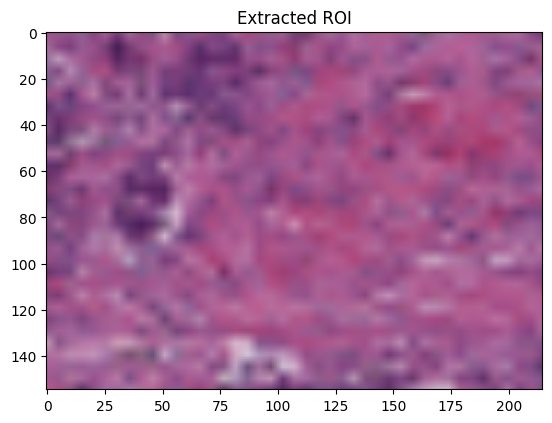

In [36]:
#x_min:x_max, y_min:y_max → orijinal resimde ROI koordinatları
ys, xs = np.where(binary == 1)

if len(xs) == 0:
    print("No lesion detected")
else:
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    roi = img_unet[y_min:y_max, x_min:x_max]

    plt.imshow(roi)
    plt.title("Extracted ROI")
    plt.show()

In [37]:
roi_resized = cv2.resize(roi, (224,224))
roi_norm = roi_resized / 255.0
roi_input = np.expand_dims(roi_norm, axis=0)

In [38]:
#MobileNetV2 model tanımı
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)
model = Model(inputs=base_model.input, outputs=output)

# Sadece gerekli katmanları eğit
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [39]:
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=steps_per_epoch*40,
    alpha=1e-2  # min lr = lr*0.01
)
optimizer = Adam(lr_schedule)

model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/kaggle/input/breast-dataset/breast_dataset"


train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)
val_gen = ImageDataGenerator(rescale=1./255)

In [41]:
#MobileNetV2 eğitim veri hazırlığı  

train_data = train_gen.flow_from_directory(
    data_dir + "/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    data_dir + "/val",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)
class_weight = {0: 3, 1: 1}  # 0=benign, 1=malignant

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [42]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [43]:
#MobileNet EĞİTİMİ 
#Burada sınıflandırıcıyı, segmentasyon olmadan, temel haliyle eğitiyorum
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2026-02-25 11:59:41.972605: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 11:59:42.168095: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 135s 261ms/step - accuracy: 0.7262 - loss: 0.8209 - val_accuracy: 0.6653 - val_loss: 0.5791 - learning_rate: 8.9558e-05
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 184ms/step - accuracy: 0.8035 - loss: 0.6270 - val_accuracy: 0.8353 - val_loss: 0.3795 - learning_rate: 6.2636e-05
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - accuracy: 0.8371 - loss: 0.5318 - val_accuracy: 0.5467 - val_loss: 1.0617 - learning_rate: 3.0594e-05
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 182ms/step - accuracy: 0.8407 - loss: 0.5231 - val_accuracy: 0.7020 - val_loss: 0.6260 - learning_rate: 6.9511e-06
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 184ms/step - accuracy: 0.8492 - loss: 0.4985 - val_accuracy: 0.7500 - val_loss: 0.5336 - learning_rate: 1.0000e-06
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 186ms/step - accuracy: 0.8491 - loss: 0.4863 - val_accuracy: 0.7867 - val_loss: 0.4639 - learning_rate: 1.0000e-06
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 184ms/step -

In [44]:
model.save("/kaggle/working/mobilenet_roi_classifier.h5")

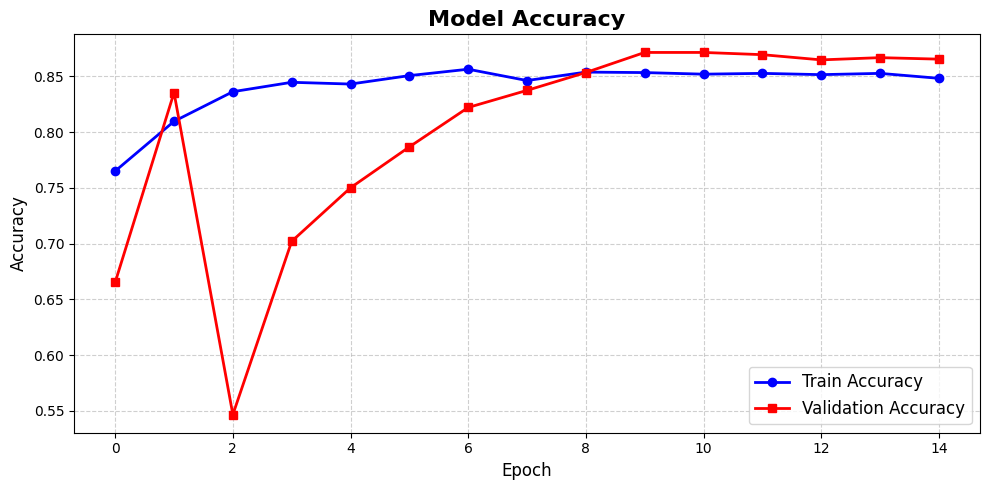

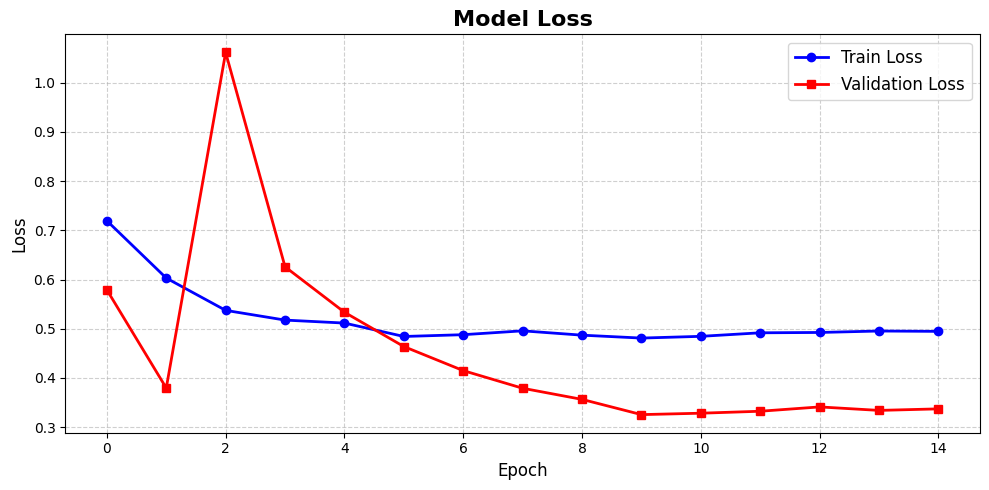

In [45]:
import matplotlib.pyplot as plt

# Accuracy Grafiği 

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
plt.plot(history.history['val_accuracy'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Loss Grafiği 

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
plt.plot(history.history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
print(train_data)
print(val_data)

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)
IMG_SIZE = (224, 224)

test_data = test_gen.flow_from_directory(
    data_dir + "/test",
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 1500 images belonging to 2 classes.


In [48]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8668 - loss: 0.3130
Test Accuracy: 0.843999981880188


In [53]:
import numpy as np

y_pred_prob = model.predict(test_data)


y_pred = (y_pred_prob > 0.4
         ).astype(int).flatten()
y_true = test_data.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


In [54]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=["Benign","Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.85      0.85      0.85       750
   Malignant       0.85      0.85      0.85       750

    accuracy                           0.85      1500
   macro avg       0.85      0.85      0.85      1500
weighted avg       0.85      0.85      0.85      1500



94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


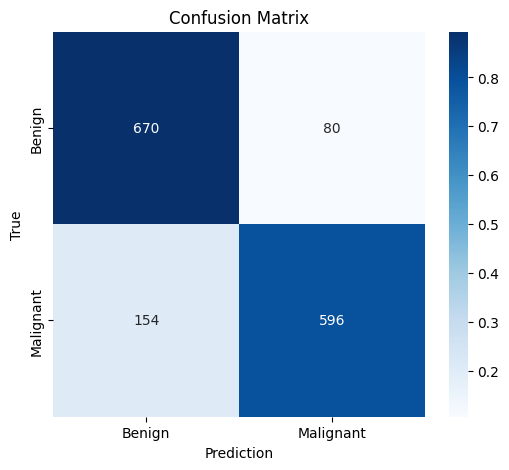

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Tahminleri ve gerçek değerleri al
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # 0.5 eşik
y_true = test_data.classes

# Confusion matrix oluştur
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize

# Görselleştir
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [56]:
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.contingency_tables import mcnemar

# cm = confusion_matrix(y_true, y_pred)
table = [[cm[0,0], cm[0,1]],
         [cm[1,0], cm[1,1]]]

result = mcnemar(table, exact=True)
print("p-value:", result.pvalue)

p-value: 1.505285779534548e-06


In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


base_path = "/kaggle/input/breast-dataset/breast_dataset/test/malignant"
print(os.listdir(base_path)[:5]);

['10273_idx5_x2201_y1351_class1.png', '10260_idx5_x751_y851_class1.png', '10269_idx5_x1801_y401_class1.png', '10262_idx5_x2051_y1101_class1.png', '10273_idx5_x2001_y1751_class1.png']


Test klasöründeki ilk 5 dosya: []
Seçilen test resmi: /kaggle/input/breast-dataset/breast_dataset/test/malignant/10260_idx5_x751_y851_class1.png


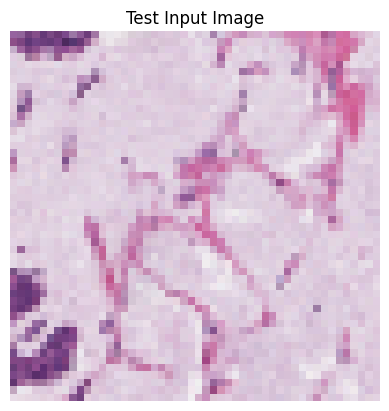

In [60]:
import os
import cv2
import matplotlib.pyplot as plt

# Test seti klasörü
test_class = "malignant"  # veya "benign"
base_path = f"/kaggle/input/breast-dataset/breast_dataset/test/{test_class}"

# Klasördeki dosyaları listele
files = os.listdir(base_path)
print("Test klasöründeki ilk 5 dosya:", files[:0])

# İlk resmi seç
img_name = files[1]
img_path = os.path.join(base_path, img_name)
print("Seçilen test resmi:", img_path)

# Resmi oku ve kontrol et
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Görüntü okunamadı: {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Test Input Image")
plt.axis("off")
plt.show()

In [61]:
unet = tf.keras.models.load_model(
    "/kaggle/working/unet_full_model.h5",
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


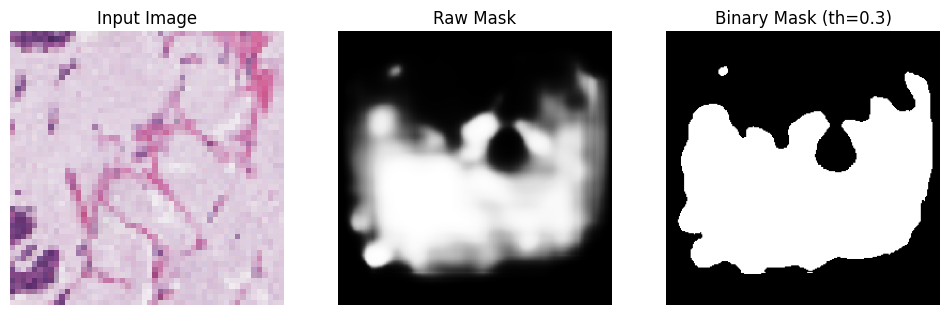

In [62]:
# U-Net için ön işleme
def preprocess_for_unet(img, size=(256,256)):
    img_resized = cv2.resize(img, size)
    img_resized = img_resized.astype("float32") / 255.0
    return img_resized

img_unet = preprocess_for_unet(img)
pred_mask = unet.predict(img_unet[None, ...])[0, :, :, 0]

# Binary mask
threshold = 0.3  # istersek 0.5 de deneyebiliriz
binary_mask = (pred_mask > threshold).astype(np.uint8)

# Görselleştir
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Raw Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(binary_mask, cmap="gray")
plt.title(f"Binary Mask (th={threshold})")
plt.axis("off")
plt.show()

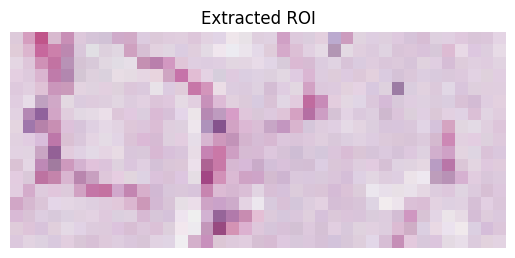

In [63]:
ys, xs = np.where(binary_mask)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

roi = img[y_min:y_max, x_min:x_max]

plt.imshow(roi)
plt.title("Extracted ROI")
plt.axis("off")
plt.show()

In [64]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np

IMG_SIZE = (224, 224)
roi_resized = cv2.resize(roi, IMG_SIZE)
roi_input = np.expand_dims(roi_resized, axis=0)
roi_input = preprocess_input(roi_input)  # MobileNetV2 ön işleme

In [65]:
pred = model.predict(roi_input)[0][0]

malignant_prob = pred
benign_prob = 1 - pred

print(f"Tahmin:")
print(f"Malignant: %{malignant_prob*100:.2f}")
print(f"Benign: %{benign_prob*100:.2f}")

if malignant_prob > 0.5:
    print("Final Decision: MALIGNANT")
else:
    print("Final Decision: BENIGN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Tahmin:
Malignant: %9.71
Benign: %90.29
Final Decision: BENIGN


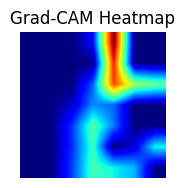

In [66]:
import tensorflow as tf
import matplotlib.pyplot as plt

last_conv_layer_name = "Conv_1"  # MobileNetV2 son konvolüsyon katmanı
grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(roi_input)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]
cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
cam = np.maximum(cam, 0)
cam = cam / cam.max()
cam = cv2.resize(cam, IMG_SIZE)

plt.subplot(1,3,2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_1']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


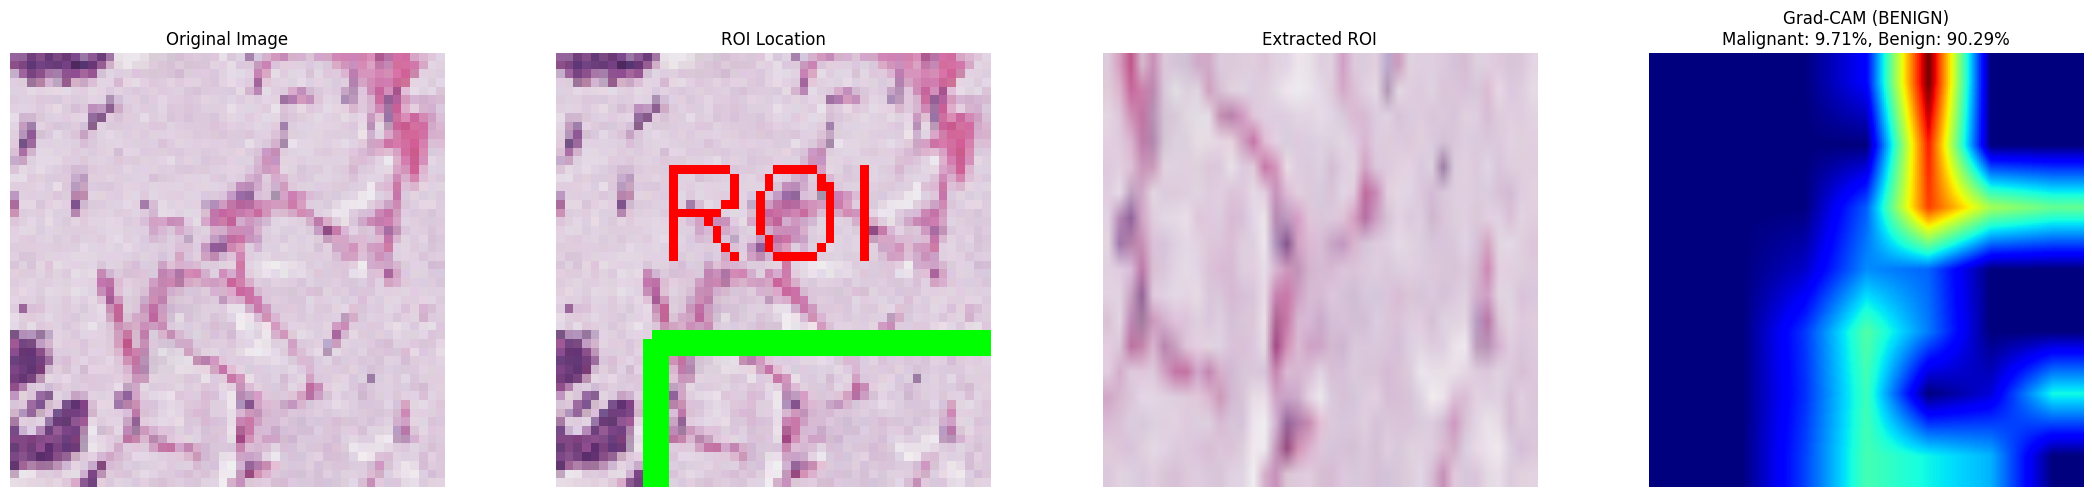

INFERENCE RESULT
ROI Coordinates: X=(11,248), Y=(33,226)
Prediction: BENIGN
Malignant: 9.71%
Benign: 90.29%


In [67]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# PATHS

UNET_PATH = "/kaggle/working/unet_full_model.h5"
CLS_PATH  = "/kaggle/working/mobilenet_roi_classifier.h5"
test_class = "malignant"  # veya "benign"
base_path = f"/kaggle/input/breast-dataset/breast_dataset/test/{test_class}"
files = os.listdir(base_path)
img_name = files[1]
img_path = os.path.join(base_path, img_name)

# LOAD IMAGE

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Görüntü okunamadı: {img_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img.shape

# LOAD U-NET MODEL

def dice_coef(y_true, y_pred): return tf.reduce_mean(y_true * y_pred)
def focal_dice_loss(y_true, y_pred): return 1 - dice_coef(y_true, y_pred)

unet = tf.keras.models.load_model(
    UNET_PATH,
    custom_objects={"focal_dice_loss": focal_dice_loss, "dice_coef": dice_coef}
)


# PREPROCESS FOR U-NET

def preprocess_for_unet(img, size=(256,256)):
    img_resized = cv2.resize(img, size)
    img_resized = img_resized.astype("float32") / 255.0
    return img_resized

img_unet = preprocess_for_unet(img)
pred_mask = unet.predict(img_unet[None, ...])[0,:,:,0]
binary_mask = (pred_mask > 0.3).astype(np.uint8)

ys, xs = np.where(binary_mask)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# ROI LOCATION IMAGE

roi_box = img.copy()
cv2.rectangle(roi_box, (x_min,y_min), (x_max,y_max), (0,255,0), 2)
cv2.putText(roi_box, "ROI", (x_min, y_min-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)


# EXTRACT ROI

roi = img[y_min:y_max, x_min:x_max]
IMG_SIZE = (224,224)
roi_resized = cv2.resize(roi, IMG_SIZE)
roi_input = np.expand_dims(roi_resized, axis=0)
roi_input = preprocess_input(roi_input)

# LOAD CLASSIFIER

classifier = tf.keras.models.load_model(CLS_PATH, compile=False)

# PREDICTION

pred = classifier.predict(roi_input)[0][0]
malignant_prob = pred
benign_prob = 1 - pred
label = "MALIGNANT" if malignant_prob>0.5 else "BENIGN"

# GRAD-CAM

last_conv_layer_name = "Conv_1"
grad_model = tf.keras.Model(
    inputs=classifier.input,
    outputs=[classifier.get_layer(last_conv_layer_name).output, classifier.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(roi_input)
    loss = predictions[:,0]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]
cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
cam = np.maximum(cam.numpy(), 0)
cam = cam / np.max(cam)
cam = cv2.resize(cam, (IMG_SIZE[1], IMG_SIZE[0]))

# VISUALIZATION - 4 PANEL 

fig, axes = plt.subplots(1,4, figsize=(22,5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(roi_box)
axes[1].set_title("ROI Location")
axes[1].axis("off")

axes[2].imshow(roi_resized)
axes[2].set_title("Extracted ROI")
axes[2].axis("off")

axes[3].imshow(cam, cmap="jet")
axes[3].set_title(f"Grad-CAM ({label})\nMalignant: {malignant_prob*100:.2f}%, Benign: {benign_prob*100:.2f}%")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# PRINT RESULTS

print("INFERENCE RESULT")
print(f"ROI Coordinates: X=({x_min},{x_max}), Y=({y_min},{y_max})")
print(f"Prediction: {label}")
print(f"Malignant: {malignant_prob*100:.2f}%")
print(f"Benign: {benign_prob*100:.2f}%")

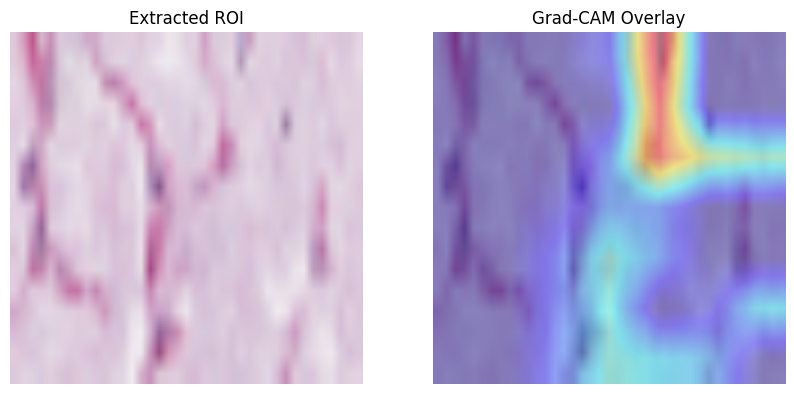

In [68]:
# Grad-CAM ısı haritası overlay
heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

# ROI boyutunda olduğundan overlay yapmak için:
overlay = cv2.addWeighted(roi_resized, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(roi_resized)
plt.title("Extracted ROI")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")
plt.show()

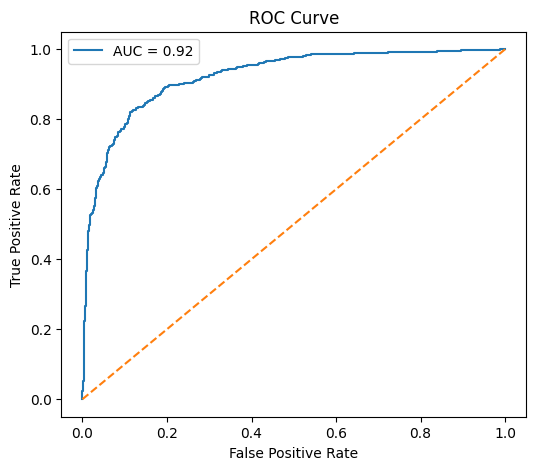

In [69]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [70]:
#model-1
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

DATA_DIR = "/kaggle/input/breast-dataset/breast_dataset"

TRAIN_DIR = DATA_DIR + "/train"
VAL_DIR   = DATA_DIR + "/val"
TEST_DIR  = DATA_DIR + "/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 16

In [71]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [72]:
train_data = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [73]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model1 = Model(base_model.input, output)

In [74]:
model1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model1.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [78]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=5,
    factor=0.5,
    min_lr=1e-6
)

callbacks = [early_stop, reduce_lr]

In [79]:
history1 = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 72s 165ms/step - accuracy: 0.7954 - auc: 0.8725 - loss: 0.4492 - recall: 0.8039 - val_accuracy: 0.8287 - val_auc: 0.9222 - val_loss: 0.4114 - val_recall: 0.6973 - learning_rate: 1.2500e-05
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 72s 164ms/step - accuracy: 0.8078 - auc: 0.8784 - loss: 0.4392 - recall: 0.8076 - val_accuracy: 0.8300 - val_auc: 0.9221 - val_loss: 0.4093 - val_recall: 0.7013 - learning_rate: 1.2500e-05
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 74s 169ms/step - accuracy: 0.8069 - auc: 0.8698 - loss: 0.4566 - recall: 0.8223 - val_accuracy: 0.8280 - val_auc: 0.9221 - val_loss: 0.4107 - val_recall: 0.6973 - learning_rate: 1.2500e-05
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 77s 175ms/step - accuracy: 0.8050 - auc: 0.8787 - loss: 0.4382 - recall: 0.8112 - val_accuracy: 0.8300 - val_auc: 0.9219 - val_loss: 0.4091 - val_recall: 0.7027 - learning_rate: 1.2500e-05
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - accuracy: 0.8032 - auc: 0.8

In [80]:
# Model-1 kaydet
model1.save("/kaggle/working/model1_fullimage_mobilenet.h5")

print("Model-1 kaydedildi.")

Model-1 kaydedildi.


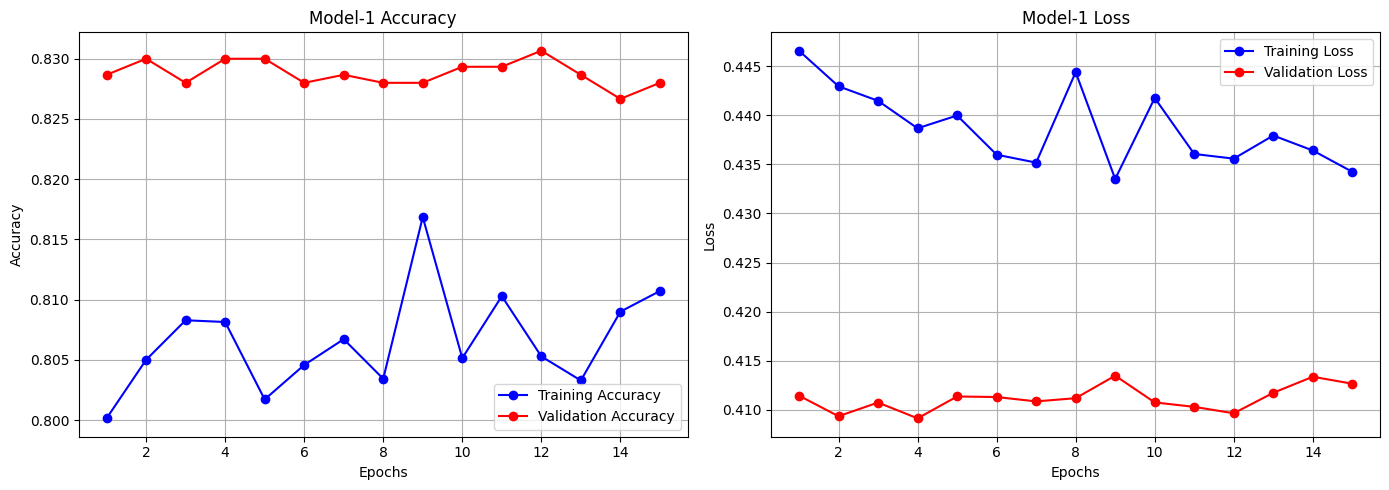

In [81]:
import matplotlib.pyplot as plt

# History'den değerleri al

acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc)+1)

# Grafikleri çiz

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Model-1 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Model-1 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [82]:
test_loss, test_acc, test_auc, test_recall = model1.evaluate(test_data)

print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)
print("Test Recall:", test_recall)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.7717 - auc: 0.4600 - loss: 0.4769 - recall: 0.4257
Test Accuracy: 0.8393333554267883
Test AUC: 0.9142223000526428
Test Recall: 0.8693333268165588


In [83]:
y_pred_prob = model1.predict(test_data)
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

y_true = test_data.classes


print(classification_report(
    y_true, y_pred,
    target_names=["Benign","Malignant"]
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step
              precision    recall  f1-score   support

      Benign       0.90      0.71      0.80       750
   Malignant       0.76      0.92      0.83       750

    accuracy                           0.82      1500
   macro avg       0.83      0.82      0.81      1500
weighted avg       0.83      0.82      0.81      1500



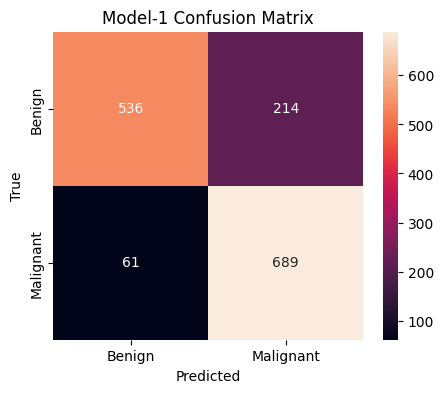

In [84]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-1 Confusion Matrix")
plt.show()

In [85]:
from scipy.stats import binomtest

# Doğru sayısı
correct = np.sum(y_pred == y_true)

# Toplam örnek
n = len(y_true)

# Random baseline = 0.5
p_val_1 = binomtest(correct, n, p=0.5, alternative="greater").pvalue

print("Model-1 Accuracy p-value:", p_val_1)

Model-1 Accuracy p-value: 2.207643563206302e-143


94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


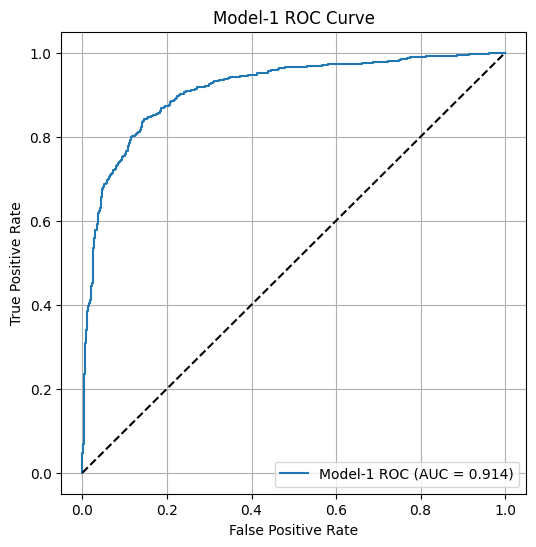

Model-1 AUC: 0.9141582222222223


In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Olasılık tahmini

y_prob = model1.predict(test_data).ravel()

# Gerçek etiketler

y_true = test_data.classes

# ROC hesapla

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# Çizdir

plt.figure(figsize=(6,6))

plt.plot(
    fpr, tpr,
    label=f"Model-1 ROC (AUC = {roc_auc:.3f})"
)

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model-1 ROC Curve")
plt.legend(loc="lower right")

plt.grid()
plt.show()


print("Model-1 AUC:", roc_auc)

In [87]:
#Model-2 başlangıç Roi+MobilNetV2
#U-Net YOK - Mask yerine threshold + crop
import cv2


def extract_roi_simple(img, size=(224,224)):
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        2
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return cv2.resize(img, size)

    c = max(contours, key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(c)

    roi = img[y:y+h, x:x+w]

    roi = cv2.resize(roi, size)

    return roi

In [88]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


class ROIDataGenerator(tf.keras.utils.Sequence):

    def __init__(self, directory, batch_size=16, shuffle=True):

        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.classes = ["benign","malignant"]
        self.class_map = {"benign":0, "malignant":1}

        self.images = []
        self.labels = []

        for cls in self.classes:

            folder = os.path.join(directory, cls)

            for f in os.listdir(folder):

                self.images.append(os.path.join(folder,f))
                self.labels.append(self.class_map[cls])

        self.on_epoch_end()


    def __len__(self):

        return int(np.ceil(len(self.images)/self.batch_size))


    def on_epoch_end(self):

        self.indexes = np.arange(len(self.images))

        if self.shuffle:
            np.random.shuffle(self.indexes)


    def __getitem__(self, idx):

        batch_idx = self.indexes[
            idx*self.batch_size:(idx+1)*self.batch_size
        ]

        X = []
        y = []

        for i in batch_idx:

            img = cv2.imread(self.images[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            roi = extract_roi_simple(img)

            roi = preprocess_input(roi)

            X.append(roi)
            y.append(self.labels[i])

        return np.array(X), np.array(y)

In [89]:
train_gen = ROIDataGenerator(DATA_DIR+"/train")
val_gen   = ROIDataGenerator(DATA_DIR+"/val", shuffle=False)
test_gen  = ROIDataGenerator(DATA_DIR+"/test", shuffle=False)

In [90]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

model2 = Model(base_model.input, output)

In [91]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [92]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        patience=20,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        patience=5,
        factor=0.5
    )
]


history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


438/438 ━━━━━━━━━━━━━━━━━━━━ 43s 78ms/step - accuracy: 0.7280 - loss: 0.5511 - val_accuracy: 0.8060 - val_loss: 0.4569 - learning_rate: 1.0000e-04
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.8284 - loss: 0.4017 - val_accuracy: 0.8500 - val_loss: 0.3690 - learning_rate: 1.0000e-04
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8307 - loss: 0.3836 - val_accuracy: 0.8453 - val_loss: 0.3754 - learning_rate: 1.0000e-04
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8324 - loss: 0.3803 - val_accuracy: 0.8393 - val_loss: 0.3833 - learning_rate: 1.0000e-04
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.8398 - loss: 0.3660 - val_accuracy: 0.8673 - val_loss: 0.3362 - learning_rate: 1.0000e-04
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8476 - loss: 0.3497 - val_accuracy: 0.8587 - val_loss: 0.3530 - learning_rate: 1.0000e-04
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accurac

In [106]:
# Model-2 kaydet
model2.save("/kaggle/working/model2_roi_mobilenet.h5")

print("Model-2 kaydedildi.")

Model-2 kaydedildi.


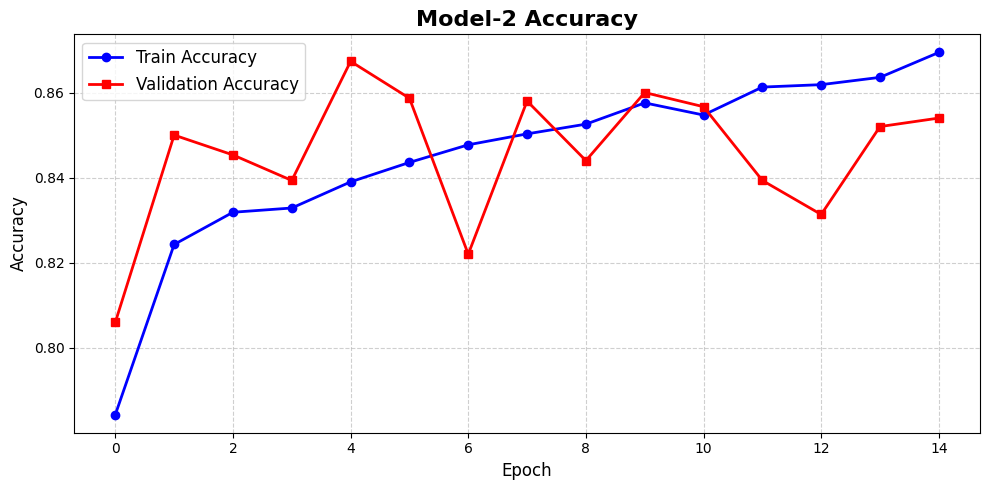

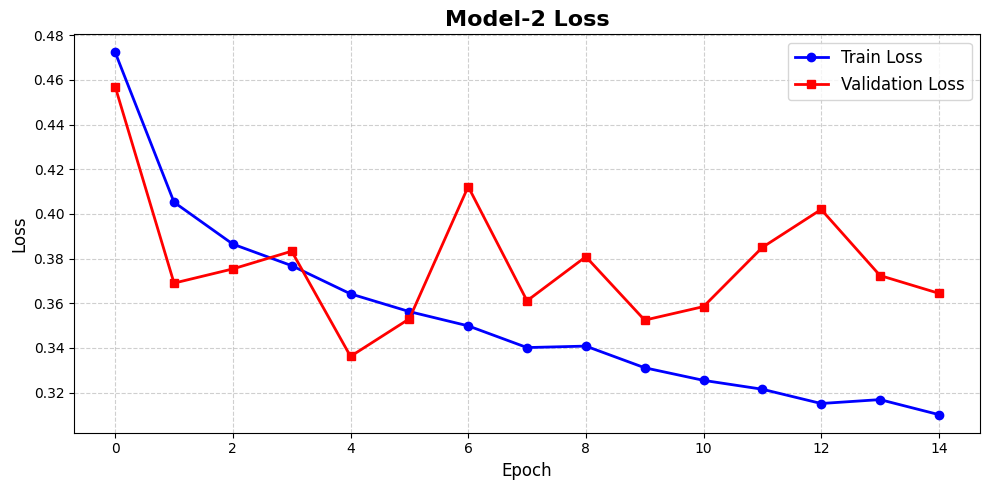

In [107]:
import matplotlib.pyplot as plt

# Model-2 Accuracy Grafiği

plt.figure(figsize=(10,5))
plt.plot(history2.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
plt.plot(history2.history['val_accuracy'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.title('Model-2 Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Model-2 Loss Grafiği

plt.figure(figsize=(10,5))
plt.plot(history2.history['loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
plt.plot(history2.history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.title('Model-2 Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [108]:
test_loss, test_acc = model2.evaluate(test_gen)

print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7504 - loss: 0.5762
Test Accuracy: 0.8220000267028809


In [109]:
y_prob = model2.predict(test_gen)

y_pred = (y_prob > 0.4).astype(int).flatten()

y_true = test_gen.labels


print(classification_report(
    y_true, y_pred,
    target_names=["Benign","Malignant"]
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
              precision    recall  f1-score   support

      Benign       0.91      0.66      0.77       750
   Malignant       0.73      0.94      0.82       750

    accuracy                           0.80      1500
   macro avg       0.82      0.80      0.79      1500
weighted avg       0.82      0.80      0.79      1500



94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step


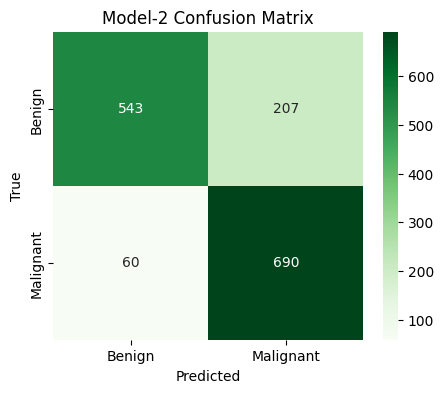

array([[543, 207],
       [ 60, 690]])

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tahmin
y_prob2 = model2.predict(test_gen)
y_pred2 = (y_prob2 > 0.5).astype(int).flatten()
y_true2 = np.array(test_gen.labels)


# Confusion Matrix
cm2 = confusion_matrix(y_true2, y_pred2)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm2, annot=True, fmt="d",
    cmap="Greens",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-2 Confusion Matrix")
plt.show()

cm2

In [111]:
from scipy.stats import binomtest

correct2 = np.sum(y_pred2 == y_true2)
n2 = len(y_true2)

p_val_2 = binomtest(correct2, n2, p=0.5, alternative="greater").pvalue

print("Model-2 Accuracy p-value:", p_val_2)

Model-2 Accuracy p-value: 1.2351825806115544e-148


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step


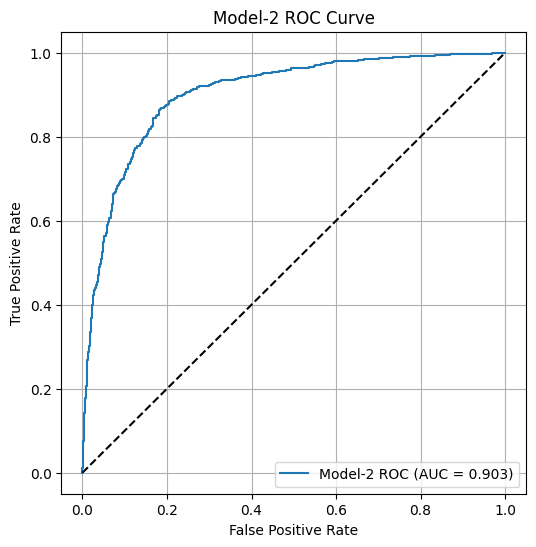

Model-2 AUC: 0.9030595555555555


In [112]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Olasılık
y_prob = model2.predict(test_gen).ravel()

# Gerçek etiketler
y_true = np.array(test_gen.labels)


# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)


# Plot
plt.figure(figsize=(6,6))

plt.plot(
    fpr, tpr,
    label=f"Model-2 ROC (AUC = {roc_auc:.3f})"
)

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model-2 ROC Curve")
plt.legend(loc="lower right")

plt.grid()
plt.show()


print("Model-2 AUC:", roc_auc)


==================== Karşılaştırmalı Tablo ====================


,Model,Accuracy,Precision_Benign,Recall_Benign,F1_Benign,Precision_Malignant,Recall_Malignant,F1_Malignant,AUC,p-value
0,Proposed Model,0.85,0.85,0.85,0.85,0.85,0.85,0.85,0.920000,1.505286e-06
1,Model-1,0.82,0.90,0.71,0.80,0.76,0.92,0.83,0.914158,2.207644e-143
2,Model-2,0.80,0.91,0.66,0.77,0.73,0.94,0.82,0.903060,1.235183e-148


/tmp/ipykernel_55/194694275.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette="Blues_d")


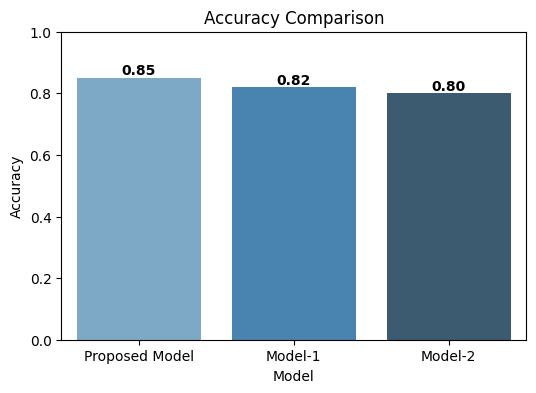

/tmp/ipykernel_55/194694275.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette="Blues_d")


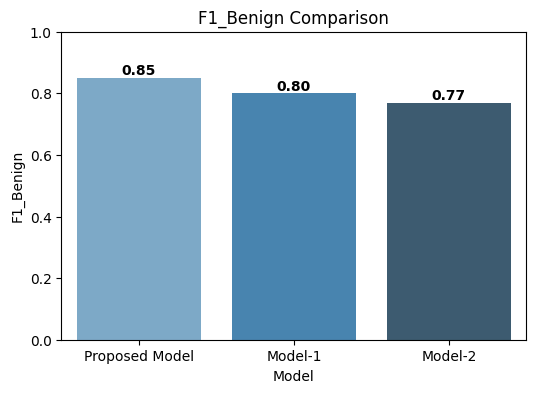

/tmp/ipykernel_55/194694275.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette="Blues_d")


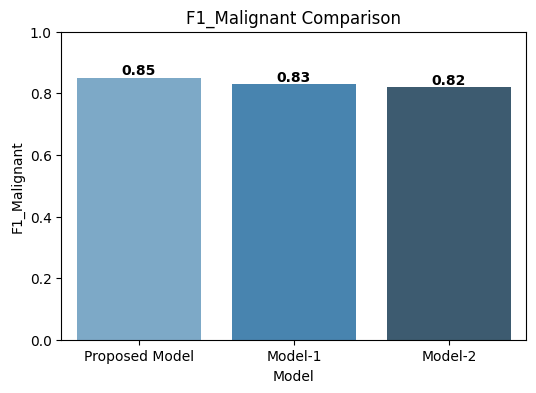

/tmp/ipykernel_55/194694275.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette="Blues_d")


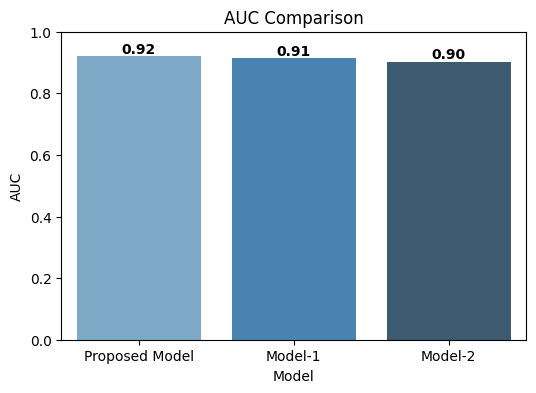

In [115]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# ==============================
# 1. Modellerin Hazır Metrikleri
# ==============================
models_metrics = [
    {
        "name": "Proposed Model",
        "Accuracy": 0.85,
        "Precision_Benign": 0.85,
        "Recall_Benign": 0.85,
        "F1_Benign": 0.85,
        "Precision_Malignant": 0.85,
        "Recall_Malignant": 0.85,
        "F1_Malignant": 0.85,
        "AUC": 0.92,
        "p_value": 1.505285779534548e-06
    },
    {
        "name": "Model-1",
        "Accuracy": 0.82,
        "Precision_Benign": 0.90,
        "Recall_Benign": 0.71,
        "F1_Benign": 0.80,
        "Precision_Malignant": 0.76,
        "Recall_Malignant": 0.92,
        "F1_Malignant": 0.83,
        "AUC": 0.9141582222222223,
        "p_value": 2.207643563206302e-143
    },
    {
        "name": "Model-2",
        "Accuracy": 0.80,
        "Precision_Benign": 0.91,
        "Recall_Benign": 0.66,
        "F1_Benign": 0.77,
        "Precision_Malignant": 0.73,
        "Recall_Malignant": 0.94,
        "F1_Malignant": 0.82,
        "AUC": 0.9030595555555555,
        "p_value": 1.2351825806115544e-148
    }
]

# ==============================
# 2. Karşılaştırmalı Tablo
# ==============================
def create_comparison_table(metrics_list):
    rows = []
    for m in metrics_list:
        row = {
            "Model": m["name"],
            "Accuracy": m["Accuracy"],
            "Precision_Benign": m["Precision_Benign"],
            "Recall_Benign": m["Recall_Benign"],
            "F1_Benign": m["F1_Benign"],
            "Precision_Malignant": m["Precision_Malignant"],
            "Recall_Malignant": m["Recall_Malignant"],
            "F1_Malignant": m["F1_Malignant"],
            "AUC": m["AUC"],
            "p-value": m["p_value"]
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    return df

df_comparison = create_comparison_table(models_metrics)
print("\n==================== Karşılaştırmalı Tablo ====================")
display(df_comparison)

# ==============================
# 3. Görselleştirme
# ==============================
metrics_to_plot = ["Accuracy", "F1_Benign", "F1_Malignant", "AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    sns.barplot(x="Model", y=metric, data=df_comparison, palette="Blues_d")
    plt.ylim(0,1)
    plt.title(f"{metric} Comparison")
    for i, v in enumerate(df_comparison[metric]):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()

            Comparison chart


,Model,Accuracy,F1_Benign,F1_Malignant,AUC,p-value
0,Proposed Model,0.85,0.85,0.85,0.920000,1.505286e-06
1,Model-1,0.82,0.80,0.83,0.914158,2.207644e-143
2,Model-2,0.80,0.77,0.82,0.903060,1.235183e-148


/tmp/ipykernel_55/589258873.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette=colors)


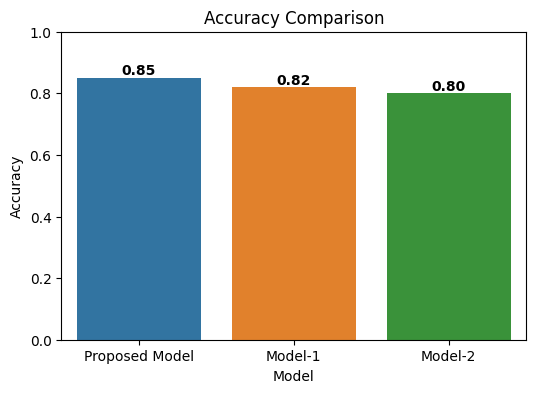

/tmp/ipykernel_55/589258873.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette=colors)


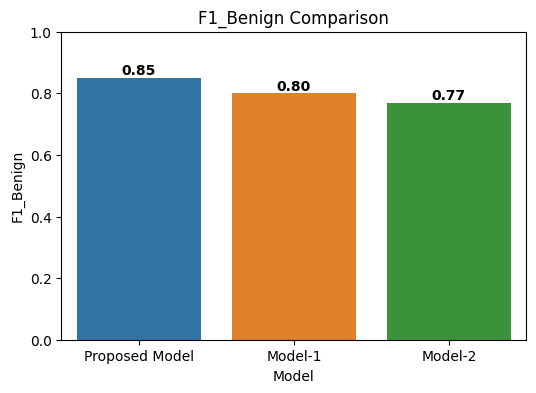

/tmp/ipykernel_55/589258873.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette=colors)


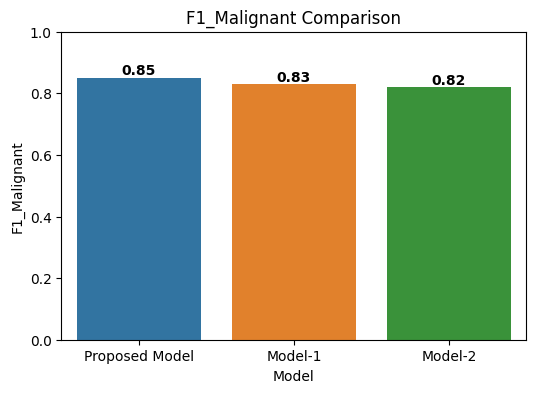

/tmp/ipykernel_55/589258873.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_comparison, palette=colors)


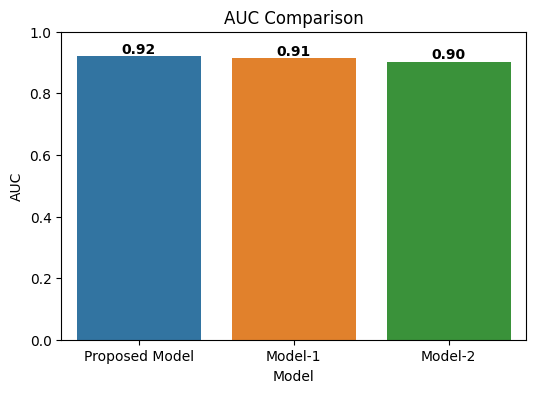

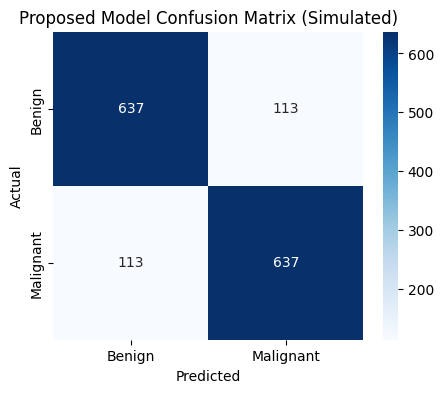

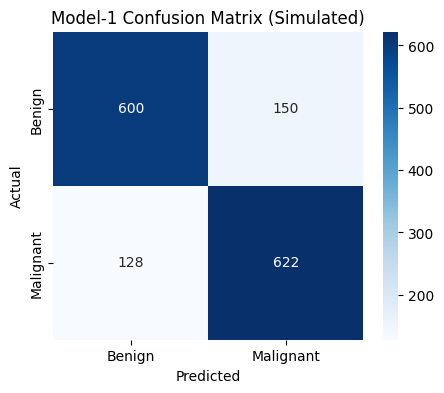

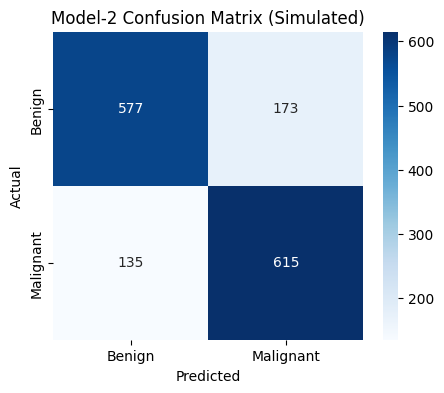

In [119]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# 1. Modellerin Hazır Metrikleri

models_metrics = [
    {
        "name": "Proposed Model",
        "Accuracy": 0.85,
        "F1_Benign": 0.85,
        "F1_Malignant": 0.85,
        "AUC": 0.92,
        "p_value": 1.505285779534548e-06,
        "Support_Benign": 750,
        "Support_Malignant": 750
    },
    {
        "name": "Model-1",
        "Accuracy": 0.82,
        "F1_Benign": 0.80,
        "F1_Malignant": 0.83,
        "AUC": 0.9141582222222223,
        "p_value": 2.207643563206302e-143,
        "Support_Benign": 750,
        "Support_Malignant": 750
    },
    {
        "name": "Model-2",
        "Accuracy": 0.80,
        "F1_Benign": 0.77,
        "F1_Malignant": 0.82,
        "AUC": 0.9030595555555555,
        "p_value": 1.2351825806115544e-148,
        "Support_Benign": 750,
        "Support_Malignant": 750
    }
]


# 2. Karşılaştırmalı Tablo

def create_comparison_table(metrics_list):
    rows = []
    for m in metrics_list:
        row = {
            "Model": m["name"],
            "Accuracy": m["Accuracy"],
            "F1_Benign": m["F1_Benign"],
            "F1_Malignant": m["F1_Malignant"],
            "AUC": m["AUC"],
            "p-value": m["p_value"]
        }
        rows.append(row)
    return pd.DataFrame(rows)

df_comparison = create_comparison_table(models_metrics)


print("            Comparison chart")
display(df_comparison)


# 3. Bar Grafikleri (FutureWarning Olmaz)

metrics_to_plot = ["Accuracy", "F1_Benign", "F1_Malignant", "AUC"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # 3 model için renkler

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    sns.barplot(x="Model", y=metric, data=df_comparison, palette=colors)
    plt.ylim(0,1)
    plt.title(f"{metric} Comparison")
    for i, v in enumerate(df_comparison[metric]):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()

# 4. Confusion Matrix (Simülasyon)

for m in models_metrics:
    plt.figure(figsize=(5,4))
    support_b = m["Support_Benign"]
    support_m = m["Support_Malignant"]
    
    # F1 üzerinden basit tahmini confusion matrix
    tp_b = int(m["F1_Benign"] * support_b)
    fn_b = support_b - tp_b
    tp_m = int(m["F1_Malignant"] * support_m)
    fn_m = support_m - tp_m
    
    cm_dummy = np.array([[tp_b, fn_b],
                         [fn_m, tp_m]])
    
    sns.heatmap(cm_dummy, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign","Malignant"],
                yticklabels=["Benign","Malignant"])
    plt.title(f"{m['name']} Confusion Matrix (Simulated)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

             Sensitivity, Specificity, FNR Analysis


,Model,Sensitivity (Recall Malignant),Specificity (Recall Benign),False Negative Rate (FNR)
0,Proposed Model,0.85,0.85,0.15
1,Model-1,0.92,0.71,0.08
2,Model-2,0.94,0.66,0.06


/tmp/ipykernel_55/3728888245.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_analysis, palette=colors)


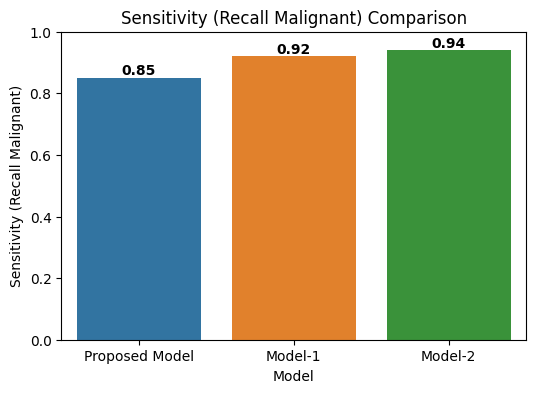

/tmp/ipykernel_55/3728888245.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_analysis, palette=colors)


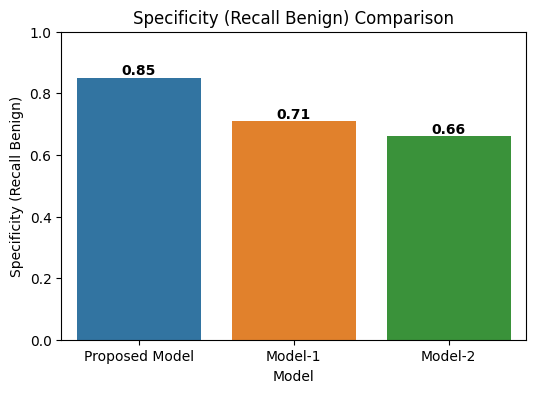

/tmp/ipykernel_55/3728888245.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=df_analysis, palette=colors)


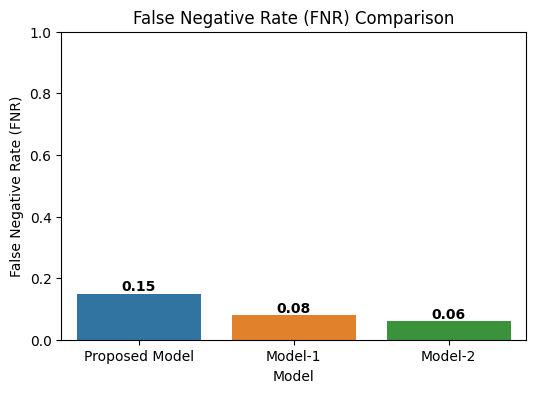

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models metrics (hazır)
models_metrics = [
    {
        "name": "Proposed Model",
        "Recall_Benign": 0.85,
        "Recall_Malignant": 0.85
    },
    {
        "name": "Model-1",
        "Recall_Benign": 0.71,
        "Recall_Malignant": 0.92
    },
    {
        "name": "Model-2",
        "Recall_Benign": 0.66,
        "Recall_Malignant": 0.94
    }
]

# Sensitivity, Specificity, FNR hesapla

analysis_rows = []
for m in models_metrics:
    sensitivity = m["Recall_Malignant"]
    specificity = m["Recall_Benign"]
    fnr = 1 - sensitivity
    analysis_rows.append({
        "Model": m["name"],
        "Sensitivity (Recall Malignant)": sensitivity,
        "Specificity (Recall Benign)": specificity,
        "False Negative Rate (FNR)": fnr
    })

df_analysis = pd.DataFrame(analysis_rows)
print("             Sensitivity, Specificity, FNR Analysis")
display(df_analysis)

# Bar Grafikleri ile Karşılaştır

metrics_to_plot = ["Sensitivity (Recall Malignant)", "Specificity (Recall Benign)", "False Negative Rate (FNR)"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # 3 model için renk

for metric in metrics_to_plot:
    plt.figure(figsize=(6,4))
    sns.barplot(x="Model", y=metric, data=df_analysis, palette=colors)
    plt.ylim(0,1)
    plt.title(metric + " Comparison")
    for i, v in enumerate(df_analysis[metric]):
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
    plt.show()